## Adaptation law of $K_d$

The desired joint stiffness is updated online from the measured normal contact force $F$ (see `stiffening_k` in `stiffening_contact.py`):

$$K_d(F) = K_{\min} + (K_{\max} - K_{\min})\,\bigl(1 - e^{-\alpha F}\bigr)$$

where:

- $F$ — measured normal contact force [N] (clamped to $F \geq 0$)
- $K_{min}$ — stiffness at zero contact force
- $K_{max}$ — saturation stiffness
- $\alpha$ — stiffening rate [1/N], swept over $\{0.0,\ 0.3,\ 2.0\}$

**Behavior:**

- $\alpha = 0 \;\Rightarrow\; K_d = K_{\min}$ throughout (passive baseline, no stiffening)
- $\alpha$ small $\;\Rightarrow\;$ gradual stiffening, with characteristic force $F_{1/2} = \ln(2)/\alpha$ (force at which $K_d$ reaches the midpoint between $K_{\min}$ and $K_{\max}$)
- $\alpha$ large $\;\Rightarrow\;$ near-immediate stiffening at first contact

The law is a saturating exponential: stiffness rises monotonically from $K_{\min}$ and asymptotically approaches $K_{\max}$ as the contact force grows. The update is applied only during the descend/ascend (motion) phases.

# Stiffening on contact — F vs d  and  K_d vs F

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, ast
from glob import glob

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'   # export exactly the displayed (PNG) figure

# Shared data box so all normal-force-vs-distance plots match the stiffness sweeps
AX_RECT = [0.15, 0.17, 0.68, 0.76]

OUTPUT_DIR  = os.path.join('outputs', 'stiffening_contact')
COLORS      = plt.rcParams['axes.prop_cycle'].by_key()['color']


def _read_constant(filepath, name):
    """Extract a numeric constant from a Python file without importing it."""
    tree = ast.parse(open(filepath).read())
    for node in ast.walk(tree):
        if (isinstance(node, ast.Assign)
                and any(isinstance(t, ast.Name) and t.id == name for t in node.targets)):
            return ast.literal_eval(node.value)
    raise KeyError(f'{name} not found in {filepath}')


_SC = os.path.join('stiffening_contact.py')
K_MIN = _read_constant(_SC, 'K_MIN')
K_MAX = _read_constant(_SC, 'K_MAX')
print(f'K_MIN={K_MIN}  K_MAX={K_MAX}  (from stiffening_contact.py)')


def available_alphas():
    """Returns sorted list of (float_value, label_str) from folder names."""
    result = []
    for folder in glob(os.path.join(OUTPUT_DIR, 'alpha_*')):
        label = os.path.basename(folder).split('_', 1)[1]
        try:
            result.append((float(label), label))
        except ValueError:
            pass
    return sorted(result)


def load_runs(label):
    pattern = os.path.join(OUTPUT_DIR, f'alpha_{label}', f'alpha_{label}_run_*.csv')
    return [pd.read_csv(f) for f in sorted(glob(pattern))]


def select_phase(df, phase='descent'):
    if 'Phase' not in df.columns:
        return df
    dff = df[df['Phase'] == phase].copy()
    if dff.empty:
        return df
    return dff


def interp_disp(dfs, col, n_pts=500, phase='descent'):
    """Interpolate runs onto a common displacement grid using one phase."""
    phase_dfs = [select_phase(df, phase).sort_values('UR5_displacement_m') for df in dfs]
    d_max = min(0.02, min(df['UR5_displacement_m'].max() for df in phase_dfs))
    d = np.linspace(0, d_max, n_pts)
    vals = np.array([np.interp(d, df['UR5_displacement_m'], df[col]) for df in phase_dfs])
    return d, vals


ALPHA_SWEEP = available_alphas()   # [(float, label_str), ...]
data = {label: load_runs(label) for _, label in ALPHA_SWEEP}
for alpha, label in ALPHA_SWEEP:
    print(f'alpha={alpha}  ->  {len(data[label])} run(s)')

K_MIN=0.1  K_MAX=0.6  (from stiffening_contact.py)
alpha=0.0  ->  5 run(s)
alpha=0.3  ->  5 run(s)
alpha=2.0  ->  5 run(s)


## F vs d

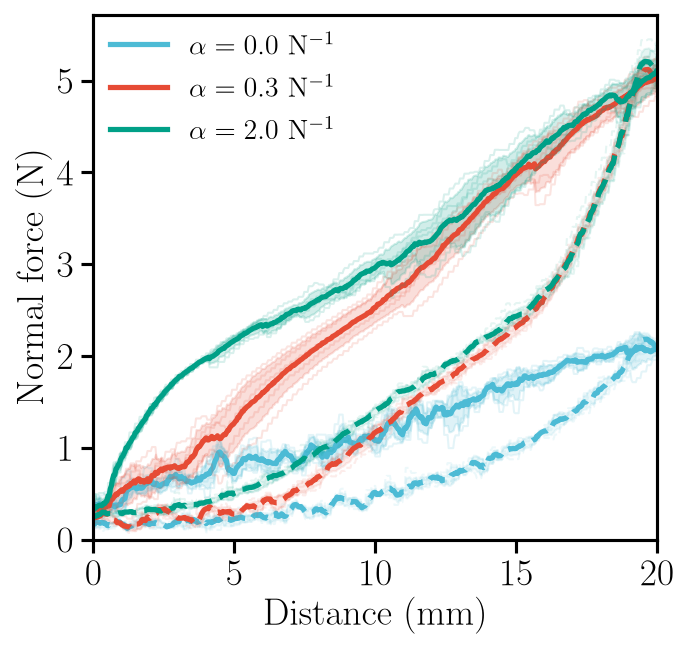

In [2]:
# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN   = 8.5 * 0.65    # figure width (inches)
ASPECT = 7.5 / 9   # height / width  ->  set to change proportions
H_IN   = W_IN * ASPECT   # figure height (inches)

fig = plt.figure(figsize=(W_IN, H_IN))
ax = fig.add_axes(AX_RECT)

phase_specs = [
    ('descent', '-',  0.15, 0.18),
    ('ascent',  '--', 0.10, 0.10),
]

for idx, (alpha, label) in enumerate(ALPHA_SWEEP):
    runs = data[label]
    if not runs:
        continue
    color = COLORS[idx % len(COLORS)]
    plot_label = rf'$\alpha = {alpha}$ N$^{{-1}}$'

    for phase, linestyle, raw_alpha, band_alpha in phase_specs:
        d, vals = interp_disp(runs, 'Force_N', phase=phase)
        d_mm = d * 1e3
        mean, std = vals.mean(0), vals.std(0)

        for v in vals:
            ax.plot(d_mm, v, color=color, alpha=raw_alpha, linewidth=1, linestyle=linestyle)
        ax.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=linestyle,
                label=plot_label if phase == 'descent' else None)
        ax.fill_between(d_mm, mean - std, mean + std, color=color, alpha=band_alpha)

ax.set_xlabel('Distance (mm)')
ax.set_ylabel('Normal force (N)')
ax.legend(loc='upper left')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'F_vs_d.pdf'))
plt.show()

## K_d vs F

In [ ]:
# ---- K_d as a function of contact force F (online adaptation law) ----
# K_d(F) = K_min + (K_max - K_min) * (1 - exp(-alpha * F))   (stiffening_contact.py)
# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN   = 8.5 * 0.52    # figure width (inches)
ASPECT = 5 / 9   # height / width  ->  set to change proportions
H_IN   = W_IN * ASPECT   # figure height (inches)

fig, ax = plt.subplots(figsize=(W_IN, H_IN))

# Plot the law across the whole contact-force range observed in the data
all_forces = [df['Force_N'].max() for runs in data.values() for df in runs if len(df)]
F_max = max(all_forces) if all_forces else 5.0
F = np.linspace(0.0, F_max, 400)


def stiffening_k(alpha, force):
    """K_d(F) = K_min + (K_max - K_min) * (1 - exp(-alpha * F))."""
    return K_MIN + (K_MAX - K_MIN) * (1.0 - np.exp(-alpha * np.maximum(force, 0.0)))


# Reference lines first (zorder low) so the law curves always stay visible on top
ax.axhline(K_MIN, color='gray', linestyle=':',  linewidth=1.2, zorder=1)
ax.axhline(K_MAX, color='gray', linestyle='--', linewidth=1.2, zorder=1)

for idx, (alpha, label) in enumerate(ALPHA_SWEEP):
    color = COLORS[idx % len(COLORS)]
    plot_label = r'$\alpha = 0$ (passive)' if alpha == 0 else rf'$\alpha = {alpha:g}$ N$^{{-1}}$'
    ax.plot(F, stiffening_k(alpha, F), color=color, linewidth=2.5, label=plot_label, zorder=3)

ax.set_xlabel('Normal force (N)')
ax.set_ylabel(r'$K_\theta$ (N$\cdot$m/rad)', y=0.4)
ax.set_xlim(0, F_max)
ax.set_ylim(0.0, K_MAX * 1.1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Kd_vs_F.pdf'))
plt.show()